# 03 — Multi-Armed Bandit
**Week 2 | Mathematical Foundations for RL**

The multi-armed bandit is the simplest RL problem: no states, just actions and stochastic rewards.
It directly introduces the **exploration vs exploitation** trade-off.

Each arm k has a true mean reward μ_k ~ N(0,1). We don't know these — we must learn them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Environment Setup

In [2]:
class Bandit:
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
        self.true_means = np.random.normal(0, 1, n_arms)  # hidden
        self.optimal_arm = np.argmax(self.true_means)

    def pull(self, arm):
        """Return a noisy reward for the chosen arm."""
        return np.random.normal(self.true_means[arm], 1.0)

bandit = Bandit(n_arms=10)
print("True arm means (hidden from agent):", np.round(bandit.true_means, 2))
print(f"Optimal arm: {bandit.optimal_arm} (mean={bandit.true_means[bandit.optimal_arm]:.2f})")

True arm means (hidden from agent): [ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]
Optimal arm: 6 (mean=1.58)


## 2. Agent Implementations

In [3]:
def run_agent(bandit, policy, n_steps=1000):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)   # estimated values
    N = np.zeros(n_arms)   # pull counts
    rewards = []
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]  # incremental mean update
        rewards.append(reward)
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(rewards), np.array(optimal_actions)

# --- Policies ---
def greedy(Q, N, t):          return np.argmax(Q)
def epsilon_greedy(eps):      return lambda Q, N, t: np.random.randint(len(Q)) if np.random.rand() < eps else np.argmax(Q)
def ucb(c=2):                 return lambda Q, N, t: np.argmax(Q + c * np.sqrt(np.log(t+1) / (N+1e-9)))

## 3. Compare Strategies over 2000 Runs

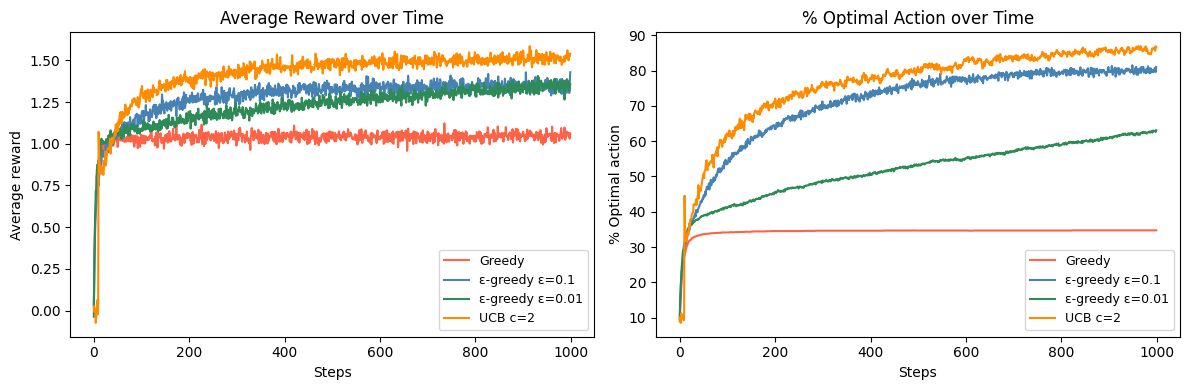

In [4]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=2',        ucb(2),              'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4. Regret Analysis
Regret = total reward you *could* have earned (always playing optimal) minus what you actually earned.

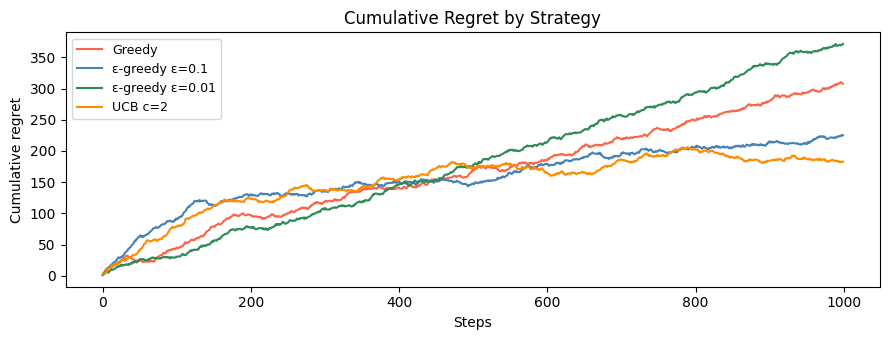

In [5]:
b = Bandit(n_arms=10)
best_mean = b.true_means.max()

plt.figure(figsize=(9, 3.5))
for label, policy, color in configs:
    b = Bandit(n_arms=10)
    # fix the same bandit for fair comparison
    b.true_means = np.array([0.2, -0.5, 1.2, 0.8, -0.1, 0.5, -0.8, 0.3, 1.5, 0.0])
    b.optimal_arm = np.argmax(b.true_means)
    best_mean = b.true_means.max()
    rewards, _ = run_agent(b, policy, N_STEPS)
    cumulative_regret = np.cumsum(best_mean - rewards)
    plt.plot(cumulative_regret, label=label, color=color, linewidth=1.5)
plt.xlabel('Steps'); plt.ylabel('Cumulative regret')
plt.title('Cumulative Regret by Strategy')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

## ✅ Exercises
1. Add a **softmax / Boltzmann** policy: pick arm proportionally to exp(Q/τ) where τ is temperature. Does it outperform ε-greedy?
2. What happens to UCB if you change c from 2 to 0.1 or 10? Re-run and plot.
3. **Challenge**: implement a **non-stationary** bandit where true means drift over time (add random noise each step). Which strategy handles this best?

## Question 1.


In [8]:
def softmax(tau=0.5):
    def policy(Q, N, t):
        # subtract max for numerical stability (prevents overflow in exp)
        scaled_Q = Q / tau
        exp_Q = np.exp(scaled_Q - np.max(scaled_Q))
        probs = exp_Q / exp_Q.sum()
        return np.random.choice(len(Q), p=probs)
    return policy

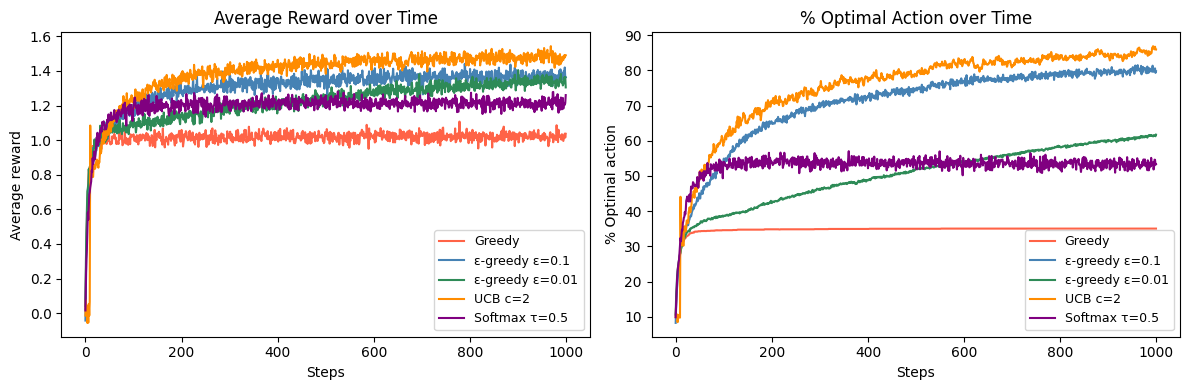

In [9]:
configs_softmax = configs + [
    ('Softmax τ=0.5', softmax(0.5), 'purple'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, policy, color in configs_softmax:
    all_rewards = np.zeros((N_RUNS, N_STEPS))
    all_optimal = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

 No softmax doesn't outperform ε-greedy here .

## Question 2.


## for c = 0.1, the change the plot.


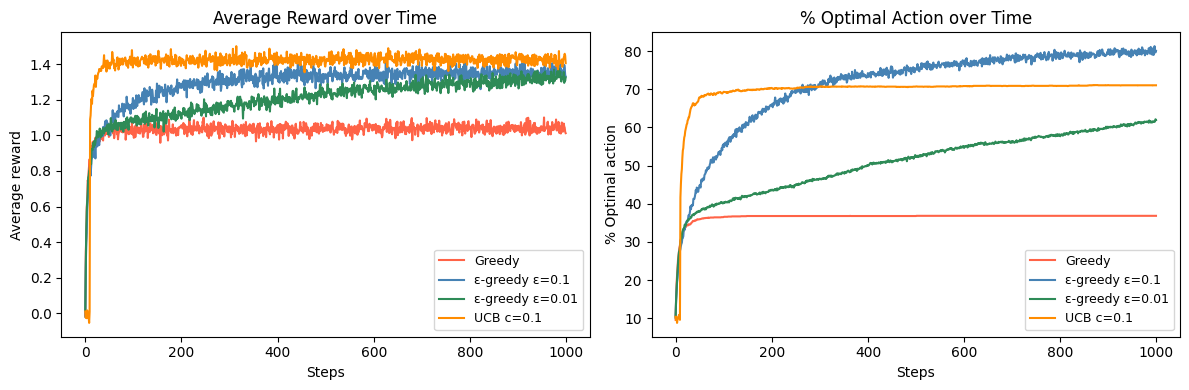

In [15]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=0.1',        ucb(0.1),              'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

 I oberved that UCB's uncertainty bonus shrinks very quickly, causing it to behave almost like a greedy policy after only a short initial exploration phase.

## for c = 10, the change the plot.


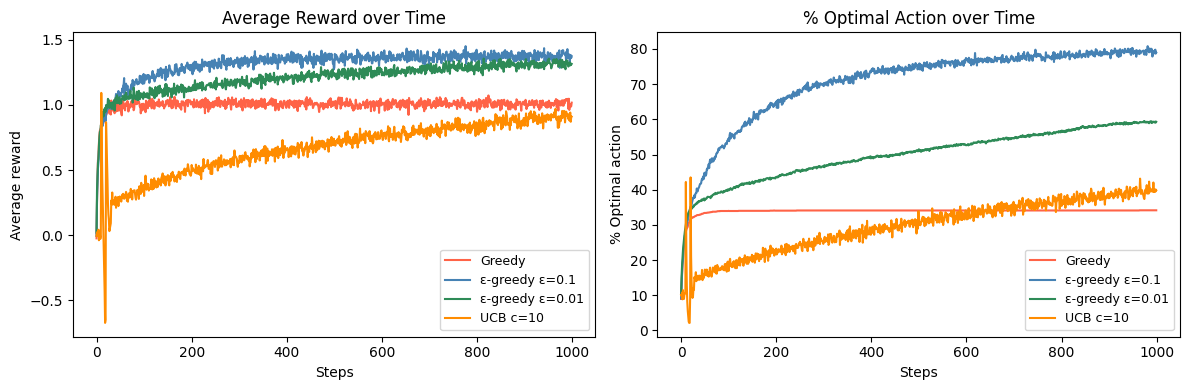

In [16]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=10',        ucb(10),              'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

I observed that UCB's uncertainty bonus completely dominates its decision-making, causing it to almost ignore the actual Q-value estimates and instead keep chasing whichever arm has been pulled least.

## Question 3.


In [17]:
class NonStationaryBandit:
    def __init__(self, n_arms=10, drift_std=0.01):
        self.n_arms = n_arms
        self.true_means = np.random.normal(0, 1, n_arms)
        self.drift_std = drift_std
        self.optimal_arm = np.argmax(self.true_means)

    def pull(self, arm):
        reward = np.random.normal(self.true_means[arm], 1.0)
        # random walk: each arm's true mean drifts slightly every step
        self.true_means += np.random.normal(0, self.drift_std, self.n_arms)
        self.optimal_arm = np.argmax(self.true_means)
        return reward

def run_agent_nonstationary(bandit, policy, n_steps=1000, alpha=0.1):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        Q[arm] += alpha * (reward - Q[arm])   # constant step-size, not 1/N
        rewards.append(reward)
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(rewards), np.array(optimal_actions)

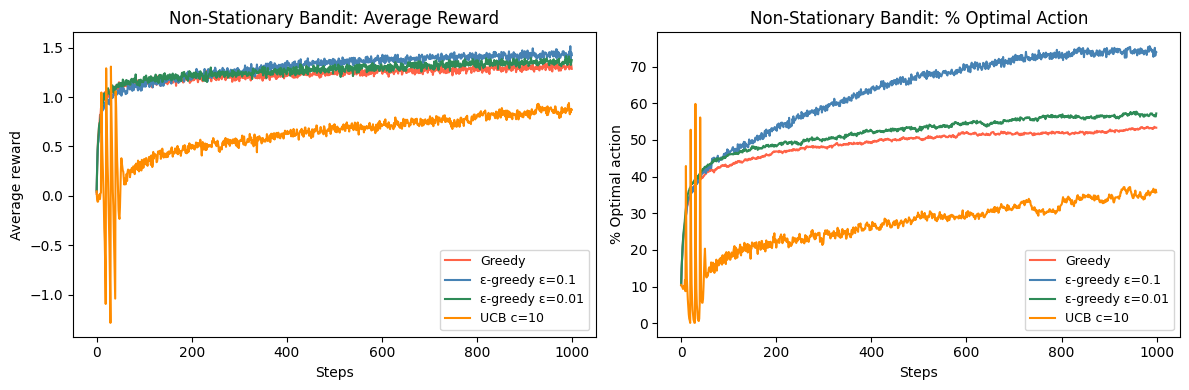

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards = np.zeros((N_RUNS, N_STEPS))
    all_optimal = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = NonStationaryBandit(n_arms=10, drift_std=0.01)
        r, opt = run_agent_nonstationary(b, policy, N_STEPS, alpha=0.1)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Non-Stationary Bandit: Average Reward'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('Non-Stationary Bandit: % Optimal Action'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Challenge Ans –** In the non-stationary bandit (where each arm's true mean drifts slightly every step), **ε-greedy ε=0.1 handled the drift best**, reaching the highest average reward and the highest % optimal action (still climbing at step 1000). This is because ε-greedy keeps exploring at a constant, fixed rate (10% of the time) throughout the entire run never "shutting off" exploration which lets it continually re-discover which arm has become the new best one as the environment drifts.

In contrast, **UCB performed poorly** in this non-stationary setting its exploration bonus shrinks as `N` (pull count) grows for each arm, so it stops re-checking arms it has already sampled a lot, even though their true means may have since drifted. This makes UCB poorly suited for non-stationary problems despite working well in the stationary case.

**Greedy and ε-greedy ε=0.01** performed similarly to each other and worse than ε=0.1 with too little (or no) ongoing exploration, they struggle to keep up with a constantly shifting optimal arm, since they rarely "look elsewhere" once they've settled on a choice.

This confirms the textbook intuition: in non-stationary problems, exploration must be **ongoing forever** (not something you finish once confident), and value estimates should use a **constant step-size** (rather than 1/N averaging) so recent rewards are weighted more heavily than stale ones from before the drift occurred.